In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import subprocess
import os

# Import de ton propre wrapper
from difmap_wrapper import DifmapSession 

# Configuration esthétique pour Matplotlib
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['axes.grid'] = True

In [2]:
fichier_original = "tests/test_data/0003-066_X.SPLIT.1"
fichier_reference = "reference_difmap.fits"

# 1. On écrit un petit script texte avec les commandes Difmap
script_difmap = f"""
observe {fichier_original}
! Ici on ne fait ni uvweight ni uvtaper, on veut la donnée brute !
wobs {fichier_reference}
quit
"""

with open("script.cmd", "w") as f:
    f.write(script_difmap)

# 2. On exécute l'ancien Difmap en tâche de fond
print("Exécution du Difmap natif en cours...")
subprocess.run(["difmap"], stdin=open("script.cmd", "r"), stdout=subprocess.DEVNULL)
print("Fichier de référence généré avec succès !")

Exécution du Difmap natif en cours...
Fichier de référence généré avec succès !


Quitting program


In [3]:
# =============================================================================
# 1. Lecture du FITS
# =============================================================================
hdul = fits.open(fichier_reference)
print("Noms des colonnes FITS :", hdul[0].data.parnames)

data_fits = hdul[0].data
u_base = data_fits['UU'] 
v_base = data_fits['VV']

# Reconstruction des 4 IFs
freq_ref = hdul[0].header.get('CRVAL4', 1.0)
if_offsets = hdul[1].data['IF FREQ'][0]
vraies_frequences = freq_ref + if_offsets

# Référence Astropy (32-bit forcé à 64-bit par NumPy)
u_ref_M = np.outer(u_base, vraies_frequences).flatten() / 1e6
v_ref_M = np.outer(v_base, vraies_frequences).flatten() / 1e6

re = data_fits['DATA'][..., 0].flatten()
im = data_fits['DATA'][..., 1].flatten()
amp_ref = np.sqrt(re**2 + im**2)

# =============================================================================
# 2.  WRAPPER PYTHON (RAM 64-bit)
# =============================================================================
session = DifmapSession()
session.observe(fichier_original)

# LIGNE CRUCIALE : on sélectionne la polarisation pour remplir la mémoire C
session.obs.select("I") 

# CORRECTION : appel direct au moteur C via _native
data_wrap = session.obs._native.get_uv_data() 
u_wrap_M = data_wrap['u'] / 1e6
v_wrap_M = data_wrap['v'] / 1e6
amp_wrap = data_wrap['amp']

print(f"\n Données extraites avec succès !")
print(f"Points Astropy : {len(u_ref_M)}")
print(f"Points Wrapper : {len(u_wrap_M)}")

Noms des colonnes FITS : ['UU', 'VV', 'WW', 'BASELINE', 'DATE', 'DATE', 'INTTIM']
Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07       

Polarization I is unavailable.


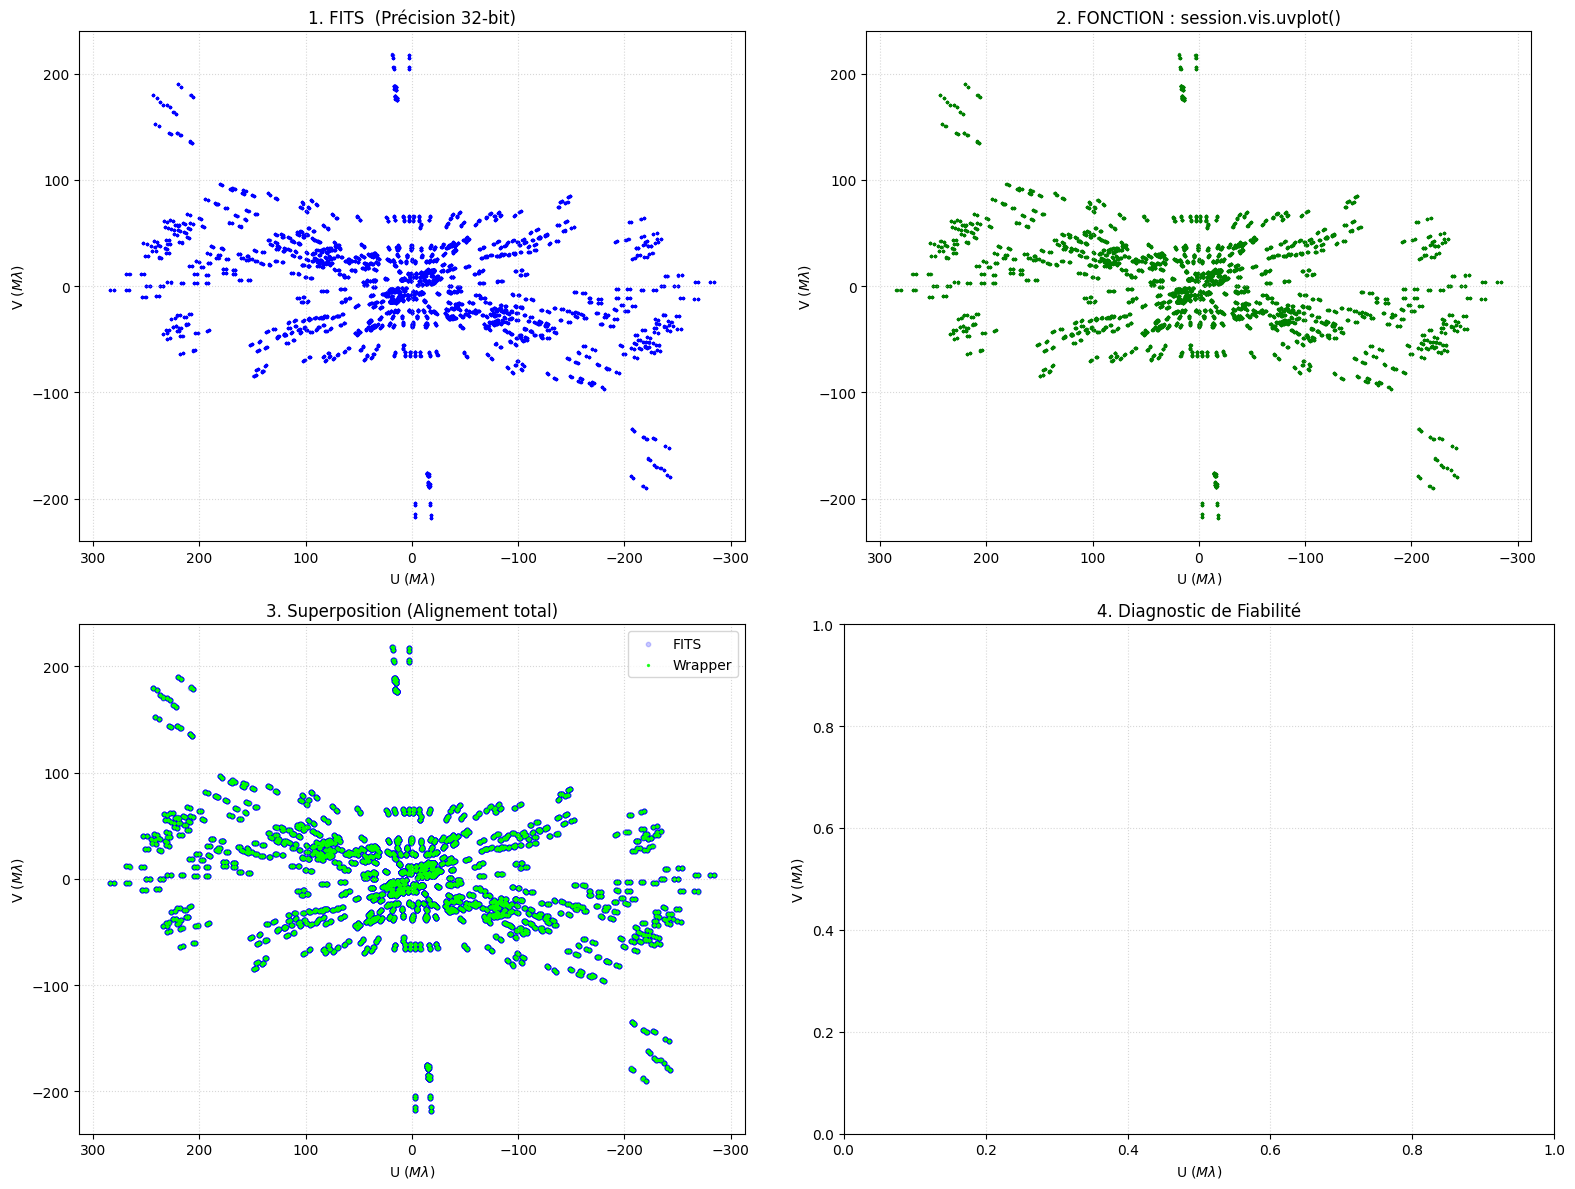

In [4]:
# Tri  pour aligner les points (U + iV)
uv_ref_c = np.sort(u_ref_M + 1j * v_ref_M)
uv_wrap_c = np.sort(u_wrap_M + 1j * v_wrap_M)

# Calcul des différences brutes
diff_u = np.real(uv_wrap_c) - np.real(uv_ref_c)
diff_v = np.imag(uv_wrap_c) - np.imag(uv_ref_c)

# Le filtre de tolérance pour le format FITS (3e-5 Mlambda)
# 1. On cherche la valeur maximale absolue dans l'observation (le point le plus loin)
max_uv = np.max(np.abs(uv_ref_c))

# 2. On calcule le seuil dynamique : Valeur Max * Epsilon du 32-bit (environ 1.5e-7)
tolerance = max_uv * 1.5e-7

distance_erreur = np.sqrt(diff_u**2 + diff_v**2)
masque_bugs = distance_erreur > tolerance

u_bugs = diff_u[masque_bugs]
v_bugs = diff_v[masque_bugs]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

# Panneau 1 : FITS Legacy (On ajoute le symétrique pour matcher avec ton uvplot)
axs[0].scatter(u_ref_M, v_ref_M, s=2, color='blue', alpha=0.4)
axs[0].scatter(-u_ref_M, -v_ref_M, s=2, color='blue', alpha=0.4)
axs[0].set_title("1. FITS  (Précision 32-bit)")

# Panneau 2 : APPEL DE TA FONCTION UVPLOT
session.vis.uvplot(ax=axs[1], color='green', s=2, alpha=0.4)
axs[1].set_title("2. FONCTION : session.vis.uvplot()")

# Panneau 3 : Superposition
axs[2].scatter(u_ref_M, v_ref_M, s=10, color='blue', alpha=0.2, label='FITS')
axs[2].scatter(-u_ref_M, -v_ref_M, s=10, color='blue', alpha=0.2)
axs[2].scatter(u_wrap_M, v_wrap_M, s=2, color='lime', alpha=0.8, label='Wrapper')
axs[2].scatter(-u_wrap_M, -v_wrap_M, s=2, color='lime', alpha=0.8)
axs[2].set_title("3. Superposition (Alignement total)")
axs[2].legend()

# Panneau 4 : Verification
if len(u_bugs) > 0:
    axs[3].scatter(u_bugs, v_bugs, s=20, color='red', edgecolors='black')
    axs[3].set_title(f"4. ALERTES : {len(u_bugs)} bugs détectés !")
else:
    axs[3].set_title("4. Diagnostic de Fiabilité")


for i in [0, 2, 3]:
    axs[i].set_xlabel(r"U ($M\lambda$)")
    axs[i].set_ylabel(r"V ($M\lambda$)")
    
for i in [0, 2]:
    axs[i].set_aspect('equal')
    axs[i].invert_xaxis()

for ax in axs: 
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
print("\n" + "="*85)
print(f"{'Index':<8} | {'U_Astropy (32-bit)':<20} | {'U_Wrapper (64-bit)':<20} | {'Différence':<12}")
print("-" * 85)

for i in range(15):
    u_a, u_w = uv_ref_c[i].real, uv_wrap_c[i].real
    print(f"{i:<8} | {u_a:<20.12f} | {u_w:<20.12f} | {u_w - u_a:<12.2e}")

print("="*85)
print(f"Écart maximum détecté = {np.max(distance_erreur):.2e} Mλ")


Index    | U_Astropy (32-bit)   | U_Wrapper (64-bit)   | Différence  
-------------------------------------------------------------------------------------
0        | -254.228140024119    | -254.228149414062    | -9.39e-06   
1        | -254.218055973295    | -254.218048095703    | 7.88e-06    
2        | -254.207938641775    | -254.207931518555    | 7.12e-06    
3        | -254.197804669908    | -254.197814941406    | -1.03e-05   
4        | -254.187654057692    | -254.187652587891    | 1.47e-06    
5        | -254.177486805129    | -254.177490234375    | -3.43e-06   
6        | -254.167286271870    | -254.167282104492    | 4.17e-06    
7        | -254.157069098263    | -254.157073974609    | -4.88e-06   
8        | -254.146818643960    | -254.146820068359    | -1.42e-06   
9        | -254.136568189657    | -254.136581420898    | -1.32e-05   
10       | -254.126284454658    | -254.126281738281    | 2.72e-06    
11       | -254.115967438964    | -254.115966796875    | 6.42e-07    
12 

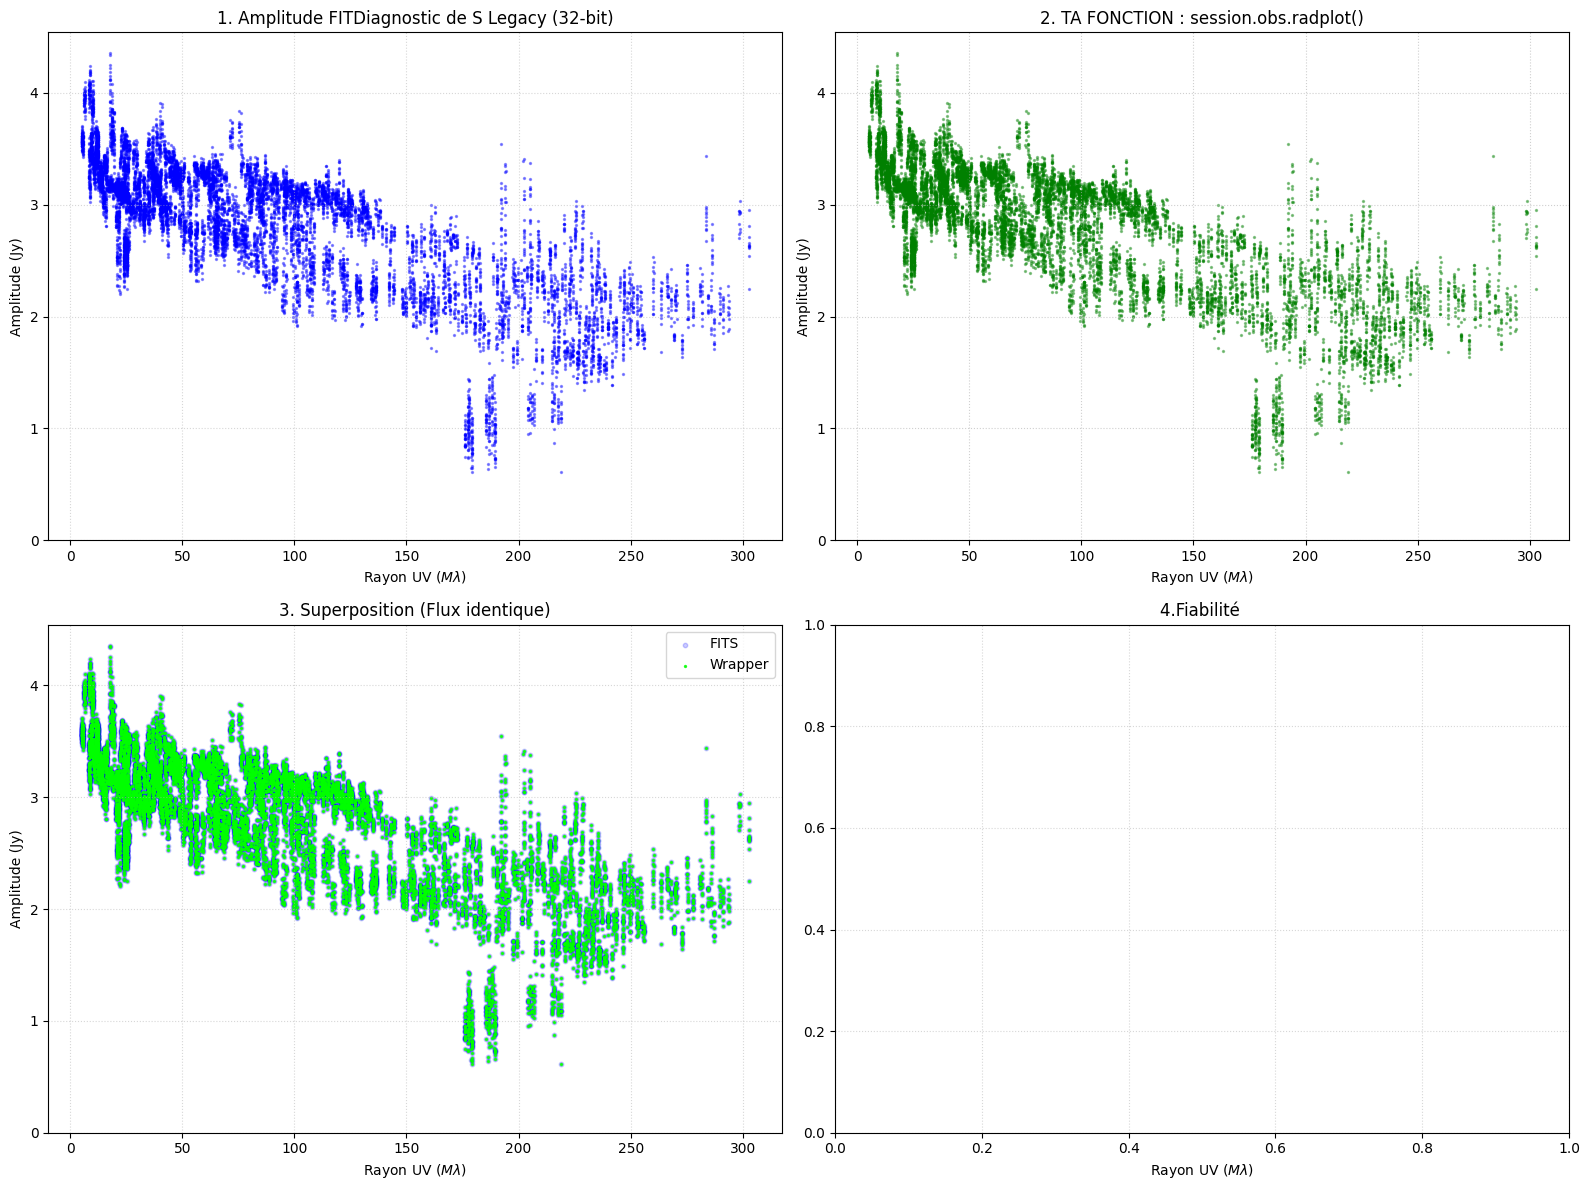


VERDICT AMPLITUDE : Erreur Max sur le flux = 0.00e+00 Jy


In [6]:
# Alignement spatial (on s'assure qu'on compare la même antenne)
idx_ref = np.argsort(u_ref_M + 1j * v_ref_M)
idx_wrap = np.argsort(u_wrap_M + 1j * v_wrap_M)

amp_ref_trie = amp_ref[idx_ref]
amp_wrap_trie = amp_wrap[idx_wrap]

# Rayon UV pour l'axe X
uv_rad_ref = np.sqrt(u_ref_M**2 + v_ref_M**2)
uv_rad_ref_trie = uv_rad_ref[idx_ref]

diff_amp = amp_wrap_trie - amp_ref_trie

# Filtre : Alerte si l'écart de flux la tolerance
# 1. On cherche le flux maximum de l'observation
max_amp = np.max(amp_ref)

# 2. On calcule le seuil dynamique 
tolerance_amp = max_amp * 1.5e-7
masque_bugs_amp = np.abs(diff_amp) > tolerance_amp
amp_bugs = diff_amp[masque_bugs_amp]
rad_bugs = uv_rad_ref_trie[masque_bugs_amp]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

# Panneau 1 : FITS Legacy
axs[0].scatter(uv_rad_ref_trie, amp_ref_trie, s=2, color='blue', alpha=0.4)
axs[0].set_title("1. Amplitude FITDiagnostic de S Legacy (32-bit)")

# Panneau 2 : APPEL DE LA FONCTION RADPLOT
session.vis.radplot(ax=axs[1], color='green', s=2, alpha=0.4)
axs[1].set_title("2. TA FONCTION : session.obs.radplot()")

# Panneau 3 : Superposition
axs[2].scatter(uv_rad_ref_trie, amp_ref_trie, s=10, color='blue', alpha=0.2, label='FITS')
axs[2].scatter(uv_rad_ref_trie, amp_wrap_trie, s=2, color='lime', alpha=0.8, label='Wrapper')
axs[2].set_title("3. Superposition (Flux identique)")
axs[2].legend()

# Panneau 4 : Verification
if len(amp_bugs) > 0:
    axs[3].scatter(rad_bugs, amp_bugs, s=20, color='red', edgecolors='black')
    axs[3].set_title(f"4. ALERTES : {len(amp_bugs)} bugs détectés !")
    axs[3].set_ylabel(r"$\Delta$ Amplitude (Jy)")
else:
    axs[3].set_title("4.Fiabilité ")

# Cosmétique : on formatte uniquement les panneaux générés manuellement
for i in [0, 2, 3]:
    axs[i].set_xlabel(r"Rayon UV ($M\lambda$)")
    axs[i].grid(True, linestyle=':', alpha=0.5)
    
    if i != 3: 
        axs[i].set_ylabel("Amplitude (Jy)")
        axs[i].set_ylim(bottom=0)


plt.tight_layout()
plt.show()

print("\n" + "="*85)
print(f"VERDICT AMPLITUDE : Erreur Max sur le flux = {np.max(np.abs(diff_amp)):.2e} Jy")
print("="*85)